# Faithfulness auditing — a visual walk-through

**The question:** does a model that predicts blood pressure actually *use* pulse
transit time (PTT), or is it right for the wrong reason?

**The setup (same in every part):** two components — a **signal** (PTT) and a
**calibration** — and a law that needs both. We build three models and audit them:

- **faithful** — uses PTT correctly
- **unfaithful** — uses PTT the *wrong* way
- **shortcut** — *ignores* PTT

**The claim:** accuracy and a linear probe give all three the same verdict; only a
**causal swap** isolates the faithful one. We'll watch that happen.

## Part 1 — The abstract task (numbers you can see)

Two scalars per sample: `PTT` and calibration `E0`. The law: `BP = 100 + 40·[2·ln(L/PTT) − ln(E0)]`. It needs both.

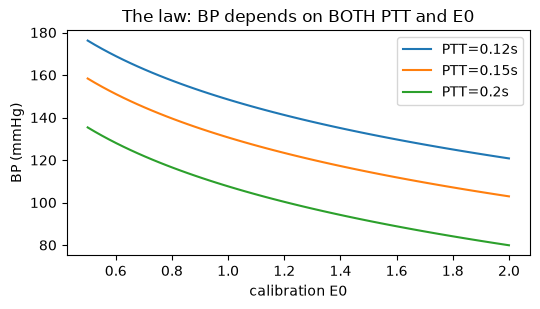

In [1]:
import numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
np.random.seed(0); torch.manual_seed(0)

L = 0.22
def law(ptt, e0):  return 2*np.log(L/ptt) - np.log(e0)        # BP = 100 + 40*law

E = np.linspace(0.5, 2.0, 60)
plt.figure(figsize=(5.5,3.2))
for p in (0.12, 0.15, 0.20):
    plt.plot(E, 100+40*law(p, E), label=f"PTT={p}s")
plt.xlabel("calibration E0"); plt.ylabel("BP (mmHg)")
plt.title("The law: BP depends on BOTH PTT and E0"); plt.legend(); plt.tight_layout(); plt.show()

**Three models.** `faithful` learns the true law; `unfaithful` learns it with the calibration term flipped; `shortcut` sees `E0` held fixed so it never needs it. Same tiny network; the state is `[encode(PTT) ; encode(E0)]`, so the audit can **swap the E0 half** between two inputs.

In [2]:
def make(n, vary_e0=True, wrong=False):
    ptt = np.random.uniform(.18, .28, n)
    e0  = np.random.uniform(.5, 2., n) if vary_e0 else np.ones(n)
    y = (2*np.log(L/ptt) + np.log(e0)) if wrong else law(ptt, e0)   # wrong = flipped E0
    t = lambda a: torch.tensor(a, dtype=torch.float32)
    return t(ptt).reshape(-1,1), t(e0).reshape(-1,1), t(y)

class Net(nn.Module):
    def __init__(s, w=16):
        super().__init__()
        s.ei = nn.Sequential(nn.Linear(1,32), nn.ReLU(), nn.Linear(32,w))   # encodes PTT
        s.ej = nn.Sequential(nn.Linear(1,32), nn.ReLU(), nn.Linear(32,w))   # encodes E0
        s.head = nn.Sequential(nn.Linear(2*w,32), nn.ReLU(), nn.Linear(32,1)); s.w = w
    def state(s, a, b):  return torch.cat([s.ei(a), s.ej(b)], 1)            # h = [PTT ; E0]
    def forward(s, a, b): return s.head(s.state(a, b)).squeeze(1)

def train(m, d, ep=300):
    opt = torch.optim.Adam(m.parameters(), 3e-3); a,b,y = d
    for _ in range(ep):
        opt.zero_grad(); ((m(a,b)-y)**2).mean().backward(); opt.step()
    return m

models = {"faithful":   train(Net(), make(3000)),
          "unfaithful": train(Net(), make(3000, wrong=True)),
          "shortcut":   train(Net(), make(3000, vary_e0=False))}
print("trained:", list(models))

trained: ['faithful', 'unfaithful', 'shortcut']


**The three audits.** *Validation* uses `E0≈fixed` (what a practitioner has); *OOD* lets `E0` vary. We measure accuracy, a linear **probe** of the answer from the state, and the **interchange**: swap the E0-half from a donor and check the output becomes what the law predicts.

In [3]:
val = make(1500, vary_e0=False); ood = make(1500)          # val: E0 fixed; ood: E0 varies
def mse(m, d):  a,b,y = d; return float(((m(a,b)-y)**2).mean())
def probe(m, d):
    a,b,y = d; H = m.state(a,b).detach().numpy()
    return r2_score(y.numpy(), Ridge().fit(H, y.numpy()).predict(H))
def interchange(m, base, src):                              # swap the E0 half of the state
    ab,eb,_ = base; asr,esr,_ = src
    hb, hs = m.state(ab,eb).detach(), m.state(asr,esr).detach(); w = m.w
    yh = m.head(torch.cat([hb[:,:w], hs[:,w:]], 1)).squeeze(1).detach().numpy()
    return r2_score(law(ab.numpy().ravel(), esr.numpy().ravel()), yh)     # graded vs the LAW

i = np.random.permutation(len(ood[2])); src = (ood[0][i], ood[1][i], ood[2][i])
clip = lambda v: float(np.clip(v,0,1)); ref = mse(models["shortcut"], ood)+1e-9
S = {r: {"validation accuracy": clip(1-mse(m,val)/ref),
         "probe R² (decode)":   clip(probe(m,val)),
         "interchange (causal)":clip(interchange(m,ood,src))} for r,m in models.items()}
for r in models: print(f"{r:11s}", {k:round(v,2) for k,v in S[r].items()})

faithful    {'validation accuracy': 1.0, 'probe R² (decode)': 1.0, 'interchange (causal)': 1.0}
unfaithful  {'validation accuracy': 1.0, 'probe R² (decode)': 1.0, 'interchange (causal)': 0.0}
shortcut    {'validation accuracy': 1.0, 'probe R² (decode)': 0.99, 'interchange (causal)': 0.32}


/tmp/ipykernel_6003/2476959353.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  def mse(m, d):  a,b,y = d; return float(((m(a,b)-y)**2).mean())


Now the scorecard — where the three models land on **“looks faithful”** for each check:

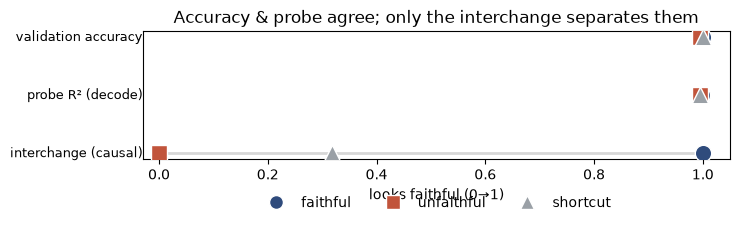

In [4]:
C = {"faithful":"#2f4b7c","unfaithful":"#c1543b","shortcut":"#9aa0a6"}
M = {"faithful":"o","unfaithful":"s","shortcut":"^"}
rows = list(S["faithful"]); ys = np.arange(len(rows))[::-1]
plt.figure(figsize=(7.5,2.8))
for y,row in zip(ys, rows):
    vals=[S[r][row] for r in models]; plt.plot([min(vals),max(vals)],[y,y],color="#d7d7d7",lw=2)
    for r in models: plt.scatter(S[r][row], y, s=140, marker=M[r], color=C[r], edgecolor="white", zorder=3)
    plt.text(-0.03, y, row, ha="right", va="center", fontsize=9)
plt.yticks([]); plt.xlim(-0.03,1.05); plt.xlabel("looks faithful (0→1)")
plt.title("Accuracy & probe agree; only the interchange separates them")
h=[plt.Line2D([],[],marker=M[r],ls="none",color=C[r],mec="white",ms=10,label=r) for r in models]
plt.legend(handles=h, ncol=3, frameon=False, loc="lower center", bbox_to_anchor=(0.5,-0.5)); plt.tight_layout(); plt.show()

## Part 2 — The BP simulator (signals you can see)

Now the `PTT` component is a real **waveform**. A pressure pulse goes down a tube
and partially reflects. We don't solve a PDE — we apply the tube's frequency
response as an FFT filter. The key fact:

$$\text{distal}(t) = (1+\Gamma)\big[\underbrace{\text{prox}(t-T)}_{\text{arrives at }T}
-\ \Gamma\,\text{prox}(t-3T)+\dots\big]\qquad \text{forward wave + echoes}$$

Let's build and look at the signals.

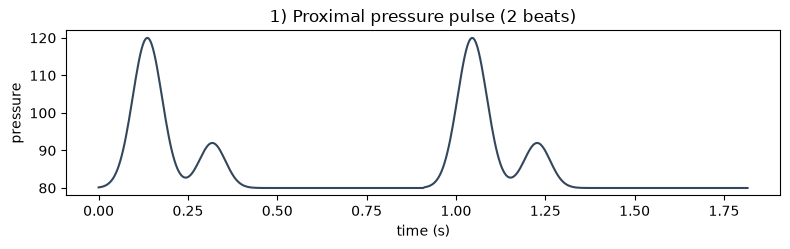

In [5]:
from bpf.simulator import make_proximal_waveform, apply_tube_load
fs, hr = 250, 66
t, prox = make_proximal_waveform(fs, hr, n_beats=2)

plt.figure(figsize=(8,2.6))
plt.plot(t, prox, color="#33475c"); plt.title("1) Proximal pressure pulse (2 beats)")
plt.xlabel("time (s)"); plt.ylabel("pressure"); plt.tight_layout(); plt.show()

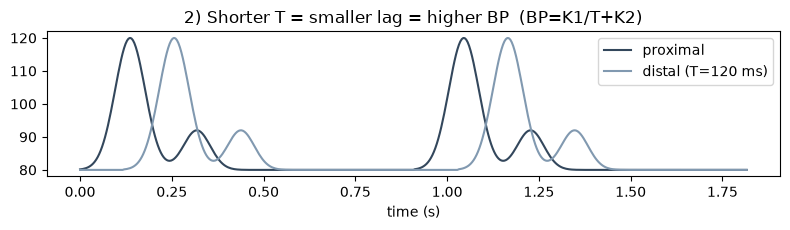

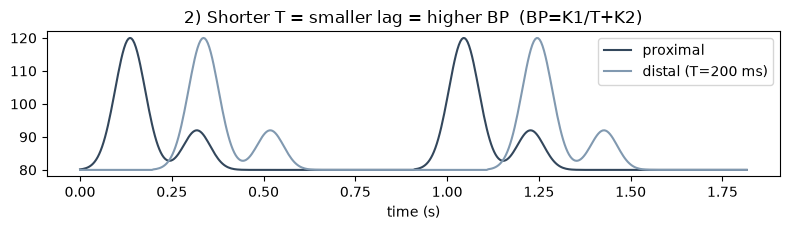

In [6]:
# 2) apply the tube: distal is the proximal pulse delayed by the transit time T
for T in (0.12, 0.20):
    dist = apply_tube_load(prox, fs, T, gamma=0.0)
    plt.figure(figsize=(8,2.4))
    plt.plot(t, prox, color="#33475c", label="proximal")
    plt.plot(t, dist, color="#8199b0", label=f"distal (T={int(T*1000)} ms)")
    plt.legend(); plt.title(f"2) Shorter T = smaller lag = higher BP  (BP=K1/T+K2)")
    plt.xlabel("time (s)"); plt.tight_layout(); plt.show()

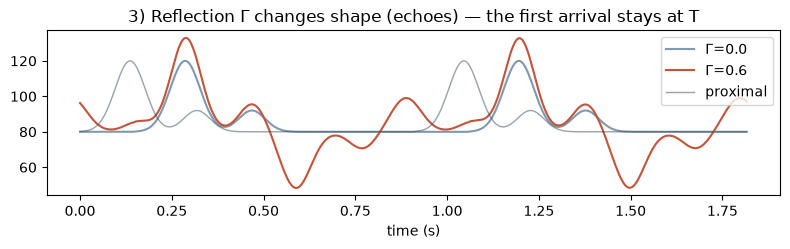

In [7]:
# 3) reflections: raising Gamma adds echoes (morphology), but the FOOT stays at T
plt.figure(figsize=(8,2.6))
for g,c in [(0.0,"#8199b0"),(0.6,"#c1543b")]:
    plt.plot(t, apply_tube_load(prox, fs, 0.15, gamma=g), color=c, label=f"Γ={g}")
plt.plot(t, prox, color="#33475c", lw=1, alpha=.5, label="proximal")
plt.legend(); plt.title("3) Reflection Γ changes shape (echoes) — the first arrival stays at T")
plt.xlabel("time (s)"); plt.tight_layout(); plt.show()

A whole dataset is just many such `(proximal, distal)` pairs with different `T` (hence different BP). A few examples, shaded by BP:

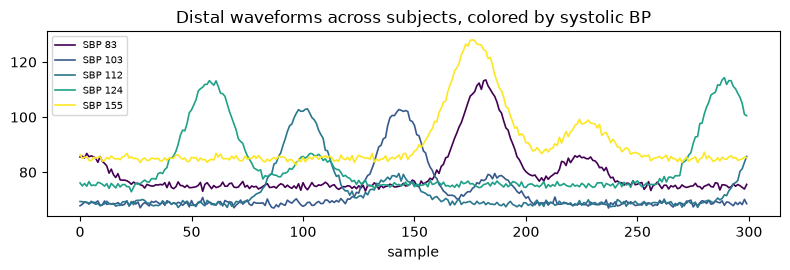

dataset: (720, 501)  BP range [83. 49.] → [155.  83.] mmHg


In [8]:
from bpf.config import load_config
from bpf.dataset import generate_dataset
cfg = load_config()
ds = generate_dataset(cfg, gamma=0.0, pep_sd_ms=0.0, seed=1)
order = np.argsort(ds.bp[:,0])
plt.figure(figsize=(8,2.8))
for k in np.linspace(0, len(order)-1, 5).astype(int):
    j = order[k]; sbp = ds.bp[j,0]
    shade = plt.cm.viridis((sbp-ds.bp[:,0].min())/np.ptp(ds.bp[:,0]))
    plt.plot(ds.dist[j][:300], color=shade, lw=1.2, label=f"SBP {sbp:.0f}")
plt.title("Distal waveforms across subjects, colored by systolic BP")
plt.xlabel("sample"); plt.legend(fontsize=7); plt.tight_layout(); plt.show()
print("dataset:", ds.prox.shape, " BP range", ds.bp.min(0).round(0), "→", ds.bp.max(0).round(0), "mmHg")

The *same* three models (faithful / unfaithful / shortcut) trained on these
waveforms give the *same* verdict as Part 1 — accuracy and the probe can't
separate them, the causal donor-swap can. Here is that result plus the tube-load
circuit (produced by `python three_models.py`):

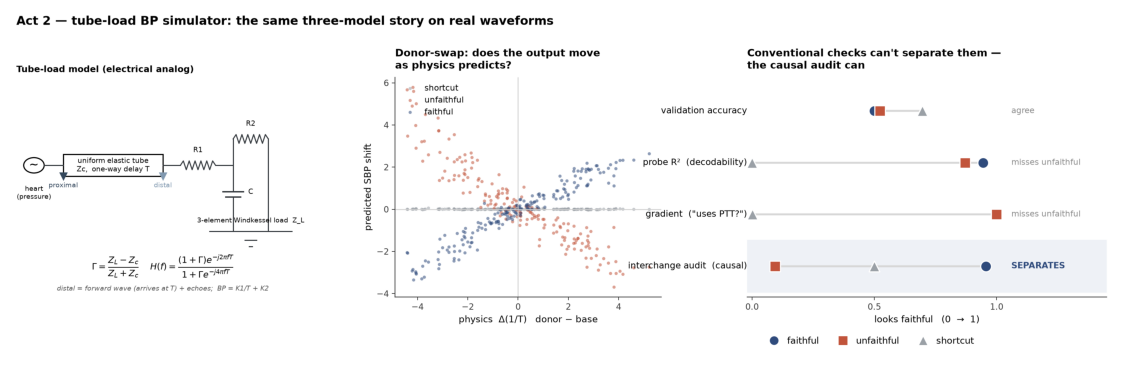

In [9]:
import matplotlib.image as mpimg
plt.figure(figsize=(15,4.5)); plt.imshow(mpimg.imread("results/bp_three_models.png")); plt.axis("off"); plt.show()

## Takeaways & where this goes

- **The audit works** in both the abstract task and on realistic tube-load waveforms:
  accuracy + linear probe agree on all three models; only the causal swap isolates
  the faithful one.
- **Architecture note:** a small CNN learns the task and encodes PTT *linearly*
  (probe R²≈0.9). A conv+cross-attention transformer also learns (best MAE) but
  encodes PTT *nonlinearly* — a **linear probe misses a faithful model** there,
  while a nonlinear probe and the causal swap recover it (`python hybrid_gate.py`).
  This is why we lean on causal audits, not linear probing alone.
- **Act 3 (real data):** proximal = ECG R-wave, distal = PPG; the interval is
  **PAT = PEP + PTT**. Same audit; see `analysis/NEXT_STEPS.md`.